# Exercise 2 - Image Compression using K-Means

Name - C S Deeraj

Roll Number is CH.SC.U4CSE24106

### Aim
To use the K-Means clustering algorithm to compress an image of size **396 x 396 x 3**.

Here, each pixel is represented by its RGB values. K-Means is used to group similar colours together and the centroid of each cluster is used as the new colour of the pixels in that cluster.

I have used **K = 16** colours for the compression. The value of K can be changed and the result can be compared with different numbers of colours.


## 1. Import the required libraries
import pandas as pd


In [12]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files
from sklearn.cluster import KMeans

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Upload the image

Now I run this cell and upload any image from my computer. The image will be converted to RGB format so that it has 3 colour channels.

In [13]:
uploaded = files.upload()

filename = next(iter(uploaded))
image = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')

print('Uploaded image:', filename)
print('Original image size:', image.size)


Saving kmeansimage.jpg to kmeansimage (1).jpg
Uploaded image: kmeansimage (1).jpg
Original image size: (738, 414)


## 3. Make the image 396 x 396

I specifically need an image of size **396 x 396 x 3**. If the uploaded image already has this size, nothing is changed. If it has a different size, it is resized to 396 x 396 before applying K-Means.

In [14]:
target_size = (396, 396)

if image.size != target_size:
    image = image.resize(target_size)
    print('Image was resized to 396 x 396.')
else:
    print('Image is already 396 x 396.')

image_array = np.array(image)

print('Image array shape:', image_array.shape)
print('Number of pixels:', image_array.shape[0] * image_array.shape[1])

Image was resized to 396 x 396.
Image array shape: (396, 396, 3)
Number of pixels: 156816


## 4. Display the original image


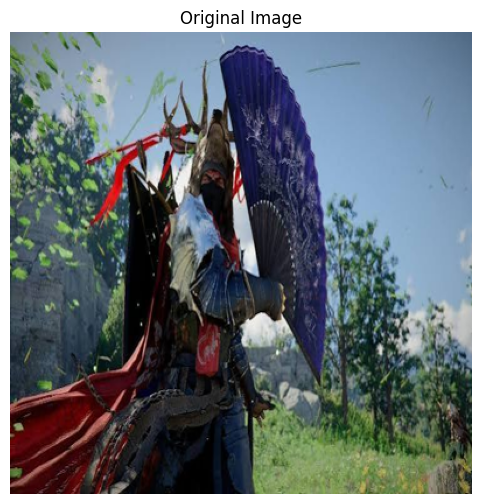

In [15]:
plt.figure(figsize=(6, 6))
plt.imshow(image_array)
plt.axis('off')
plt.title('Original Image')
plt.show()

## 5. Prepare the image for K-Means

The image has shape `(396, 396, 3)`. For K-Means, every pixel is treated as one data point with 3 features: **Red, Green and Blue**.

So the image is reshaped from `(396, 396, 3)` to `(156816, 3)`.

In [16]:
pixels = image_array.reshape(-1, 3)

print('Image shape:', image_array.shape)
print('Pixel matrix shape:', pixels.shape)
print('\nFirst 5 pixels:')
print(pixels[:5])

Image shape: (396, 396, 3)
Pixel matrix shape: (156816, 3)

First 5 pixels:
[[108 122 131]
 [108 122 131]
 [109 123 134]
 [110 123 138]
 [110 123 141]]


## 6. Apply K-Means clustering

Each cluster represents one group of similar colours. After clustering, the centroid of a cluster is used as the representative colour for all pixels belonging to that cluster.

In [17]:
K = 16

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = kmeans.fit_predict(pixels)

centroids = np.clip(kmeans.cluster_centers_, 0, 255).astype(np.uint8)

print('K-Means completed.')
print('Number of clusters (colours):', K)
print('Inertia:', round(kmeans.inertia_, 2))

K-Means completed.
Number of clusters (colours): 16
Inertia: 58670884.14


## 7. Create the compressed image

The original RGB value of every pixel is replaced by the RGB value of the centroid of the cluster to which that pixel belongs.

In [18]:
compressed_pixels = centroids[labels]
compressed_array = compressed_pixels.reshape(396, 396, 3)

compressed_image = Image.fromarray(compressed_array)

print('Compressed image shape:', compressed_array.shape)

Compressed image shape: (396, 396, 3)


## 8. Compare the original and compressed images


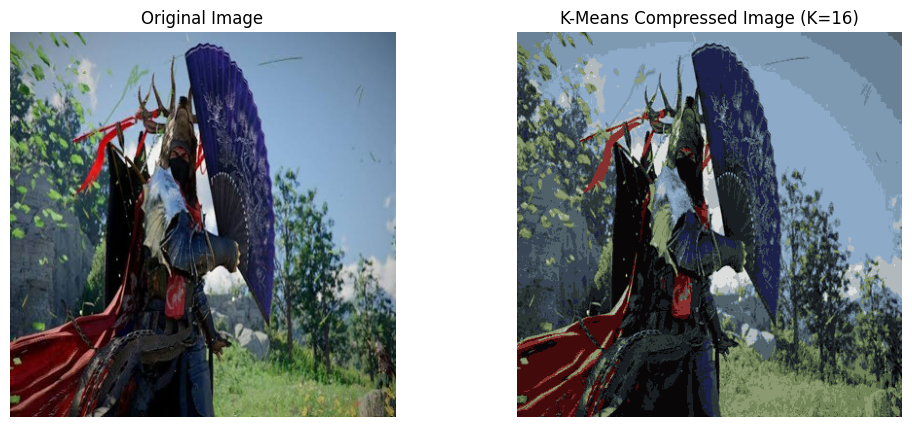

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.axis('off')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(compressed_array)
plt.axis('off')
plt.title(f'K-Means Compressed Image (K={K})')

plt.show()

## 9. Display the colours obtained from K-Means

The centroids are the representative RGB colours found by K-Means.

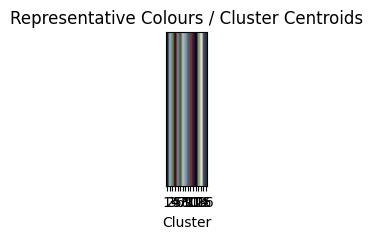

RGB values of the cluster centroids:
Cluster 1: (np.uint8(24), np.uint8(30), np.uint8(33))
Cluster 2: (np.uint8(141), np.uint8(171), np.uint8(200))
Cluster 3: (np.uint8(112), np.uint8(132), np.uint8(87))
Cluster 4: (np.uint8(67), np.uint8(10), np.uint8(12))
Cluster 5: (np.uint8(106), np.uint8(130), np.uint8(151))
Cluster 6: (np.uint8(77), np.uint8(94), np.uint8(64))
Cluster 7: (np.uint8(178), np.uint8(185), np.uint8(188))
Cluster 8: (np.uint8(126), np.uint8(154), np.uint8(179))
Cluster 9: (np.uint8(81), np.uint8(97), np.uint8(105))
Cluster 10: (np.uint8(135), np.uint8(46), np.uint8(47))
Cluster 11: (np.uint8(28), np.uint8(33), np.uint8(75))
Cluster 12: (np.uint8(9), np.uint8(6), np.uint8(8))
Cluster 13: (np.uint8(140), np.uint8(154), np.uint8(113))
Cluster 14: (np.uint8(220), np.uint8(222), np.uint8(222))
Cluster 15: (np.uint8(56), np.uint8(69), np.uint8(84))
Cluster 16: (np.uint8(43), np.uint8(54), np.uint8(52))


In [20]:
plt.figure(figsize=(10, 2))

colour_bar = np.zeros((60, K, 3), dtype=np.uint8)
colour_bar[:] = centroids

plt.imshow(colour_bar)
plt.xticks(range(K), range(1, K + 1))
plt.yticks([])
plt.xlabel('Cluster')
plt.title('Representative Colours / Cluster Centroids')
plt.show()

print('RGB values of the cluster centroids:')
for i, rgb in enumerate(centroids, start=1):
    print(f'Cluster {i}: {tuple(rgb)}')

## 10. Check the image quality after compression

Mean Squared Error (MSE) can be used to measure the difference between the original image and the compressed image. A smaller MSE means that the compressed image is closer to the original image.

In [21]:
original_float = image_array.astype(np.float32)
compressed_float = compressed_array.astype(np.float32)

mse = np.mean((original_float - compressed_float) ** 2)

if mse == 0:
    psnr = float('inf')
else:
    psnr = 10 * np.log10((255 ** 2) / mse)

print('Mean Squared Error (MSE):', round(float(mse), 4))
print('PSNR:', 'infinite' if np.isinf(psnr) else f'{psnr:.2f} dB')

Mean Squared Error (MSE): 125.1557
PSNR: 27.16 dB


## 11. Optional: Try different numbers of colours

A smaller K means fewer colours and usually more compression, but the image may lose more detail. A larger K keeps more colours and usually gives better visual quality.

The following cell compares a few K values. This is only an additional experiment; the required compressed image above uses **K = 16**.

In [22]:
test_K = [2, 4, 8, 16, 32]
mse_values = []

# Use a random sample of pixels for this optional comparison so it runs faster.
rng = np.random.default_rng(42)
sample_size = min(10000, len(pixels))
sample_indices = rng.choice(len(pixels), size=sample_size, replace=False)
sample_pixels = pixels[sample_indices]

for k_test in test_K:
    model = KMeans(n_clusters=k_test, random_state=42, n_init=10)
    sample_labels = model.fit_predict(sample_pixels)
    sample_centroids = np.clip(model.cluster_centers_, 0, 255)
    reconstructed = sample_centroids[sample_labels]
    mse_test = np.mean((sample_pixels.astype(np.float32) - reconstructed.astype(np.float32)) ** 2)
    mse_values.append(mse_test)

results = pd.DataFrame({'K': test_K, 'Sample MSE': np.round(mse_values, 2)})
display(results)

,K,Sample MSE
0,2,981.559998
1,4,438.450012
2,8,232.800003
3,16,125.360001
4,32,64.040001


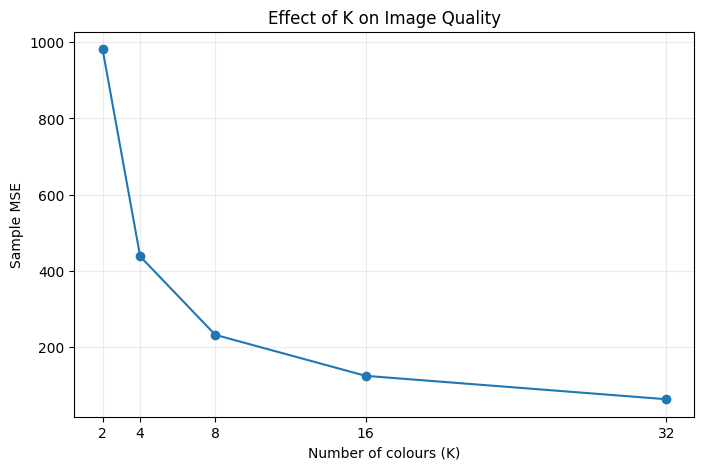

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(test_K, mse_values, marker='o')
plt.xlabel('Number of colours (K)')
plt.ylabel('Sample MSE')
plt.title('Effect of K on Image Quality')
plt.xticks(test_K)
plt.grid(alpha=0.25)
plt.show()

## 12. Optional: Save the compressed image

The compressed image can be saved as a PNG file and downloaded from Colab.

In [24]:
output_name = f'compressed_image_K{K}.png'
compressed_image.save(output_name)

print('Saved:', output_name)
files.download(output_name)

Saved: compressed_image_K16.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Result

K-Means clustering was used to compress the image by reducing the number of unique colours. The RGB pixels were grouped into **16 clusters**, and each pixel was replaced by the centroid colour of its cluster.

The original image has 256 possible values for each of the three RGB channels, while the K-Means result represents the image using only **16 representative colours**. The original and compressed images, along with the error measurement, are shown above.